# Inference Notebook
- This notebook imports a trained model and generates new samples.
- Edit the Checkpoint and Configs cell plus the sample-parameter cells to run your own inference.
- This version supports conditional generation for bass, guitar, and keyboard.
- Have fun creating new sounds!

*(NOTE: Do not use Run All in this notebook; run cells section-by-section.)*

#### Imports
Import necessary libraries to run the notebook

In [1]:
# Imports
import importlib
import matplotlib.pyplot as plt
import re
import torch
import torchaudio
from torch import nn
from torch.nn import functional as F
import pytorch_lightning as pl
from ema_pytorch import EMA
import IPython.display as ipd
import yaml
import soundfile as sf
from audio_diffusion_pytorch import DiffusionModel, UNetV0, VDiffusion, VSampler
import main.diffusion_module as diffusion_module

diffusion_module = importlib.reload(diffusion_module)
Model = diffusion_module.Model
ConditionalModel = diffusion_module.ConditionalModel
if not hasattr(diffusion_module, "EmbeddingConditionalModel"):
    raise ImportError("EmbeddingConditionalModel is missing in main.diffusion_module")
EmbeddingConditionalModel = diffusion_module.EmbeddingConditionalModel
UNetT = diffusion_module.UNetT

/home/sammli/tiny-audio-diffusion/venv/lib/python3.12/site-packages/pytorch_lightning/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/sammli/tiny-audio-diffusion/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Checkpoint & Configs
- Replace these paths with the path to your model's checkpoint and configs.
- Pre-trained models are availlable to download on Hugging Face.

|Model|Link|
|---|---|
|Kicks|[crlandsc/tiny-audio-diffusion-kicks](https://huggingface.co/crlandsc/tiny-audio-diffusion-kicks)|
|Snares|[crlandsc/tiny-audio-diffusion-snares](https://huggingface.co/crlandsc/tiny-audio-diffusion-snares)|
|Hi-hats|[crlandsc/tiny-audio-diffusion-hihats](https://huggingface.co/crlandsc/tiny-audio-diffusion-hihats)|
|Percussion (all drum types)|[crlandsc/tiny-audio-diffusion-percussion](https://huggingface.co/crlandsc/tiny-audio-diffusion-percussion)|

In [2]:
# Load model checkpoint and config (switch active_variant to test onehot vs embedding)
model_variants = {
    "onehot": {
        "ckpt_path": "logs/ckpts/2026-04-19-17-22-41/epoch=141-valid_loss=0.033.ckpt",
        "config_path": "exp/nsynth_conditional_16gb_no_wandb.yaml",
        "text_prompt": "class:guitar",
        "condition_vector": [0.0, 1.0, 0.0],
        "conditioning_mode_override": "onehot",
    },
    "embedding": {
        "ckpt_path": "logs/ckpts/2026-04-19-19-01-59/epoch=702-valid_loss=0.033.ckpt",
        "config_path": "exp/nsynth_conditional_16gb_embedding_no_wandb.yaml",
        "text_prompt": "class:bass",
        "condition_vector": [1.0, 0.0, 0.0],
        "conditioning_mode_override": "label_embedding",
    },
}

active_variant = "onehot"  # onehot | embedding
if active_variant not in model_variants:
    raise ValueError(f"Unknown active_variant '{active_variant}'.")

variant = model_variants[active_variant]
ckpt_path = variant["ckpt_path"]
config_path = variant["config_path"]
default_text_prompt = variant["text_prompt"]
default_condition_vector = variant["condition_vector"]
conditioning_mode_override = variant.get("conditioning_mode_override")

print(f"Active variant: {active_variant}")
print(f"Checkpoint: {ckpt_path}")
print(f"Config: {config_path}")
print(f"conditioning_mode_override: {conditioning_mode_override}")

Active variant: onehot
Checkpoint: logs/ckpts/2026-04-19-17-22-41/epoch=141-valid_loss=0.033.ckpt
Config: exp/nsynth_conditional_16gb_no_wandb.yaml
conditioning_mode_override: onehot


### Functions & Models
- Functions and models definitions

In [3]:
# Load config and resolve simple ${key} references used by this notebook
with open(config_path, "r", encoding="utf-8") as file:
    raw_config = yaml.safe_load(file)

def _resolve_simple_refs(value, root):
    if isinstance(value, dict):
        return {k: _resolve_simple_refs(v, root) for k, v in value.items()}
    if isinstance(value, list):
        return [_resolve_simple_refs(v, root) for v in value]
    if isinstance(value, str) and value.startswith("${") and value.endswith("}"):
        key = value[2:-1]
        return root.get(key, value)
    return value

config = _resolve_simple_refs(raw_config, raw_config)

pl_configs = config["model"]
model_configs = config["model"]["model"]
model_target = str(config["model"].get("_target_", ""))
is_embedding_model = "EmbeddingConditionalModel" in model_target
is_conditional = ("ConditionalModel" in model_target) or is_embedding_model

if conditioning_mode_override is not None:
    pl_configs["conditioning_mode"] = conditioning_mode_override

conditioning_mode = pl_configs.get("conditioning_mode", "onehot")
conditioning_dim = int(pl_configs.get("conditioning_dim", config.get("conditioning_dim", 3)))
class_names = ["bass", "guitar", "keyboard"]

print("Loaded config:", config_path)
print("model_target:", model_target)
print("conditional:", is_conditional, "embedding_model:", is_embedding_model, "mode:", conditioning_mode, "conditioning_dim:", conditioning_dim)

Loaded config: exp/nsynth_conditional_16gb_no_wandb.yaml
model_target: ${module}.ConditionalModel
conditional: True embedding_model: False mode: onehot conditioning_dim: 3


In [4]:
def plot_mel_spectrogram(sample):
    transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sr,
        n_fft=1024,
        hop_length=512,
        n_mels=80,
        center=True,
        norm="slaney",
    )

    spectrogram = transform(torch.mean(sample, dim=0)) # downmix and cal spectrogram
    spectrogram = torchaudio.functional.amplitude_to_DB(spectrogram, 1.0, 1e-10, 80.0)

    # Plot the Mel spectrogram
    fig = plt.figure(figsize=(7, 4))
    plt.imshow(spectrogram, aspect='auto', origin='lower')
    plt.colorbar(format='%+2.0f dB')
    plt.xlabel('Frame')
    plt.ylabel('Mel Bin')
    plt.title('Mel Spectrogram')
    plt.tight_layout()
    
    return fig

In [5]:
# Use training module wrappers directly so inference matches training architecture.
# This cell intentionally imports concrete classes instead of redefining them in-notebook.
_ = (Model, ConditionalModel, EmbeddingConditionalModel, UNetT, DiffusionModel, VDiffusion, VSampler, UNetV0, nn, pl, EMA)
print("Using model wrappers from main.diffusion_module")

Using model wrappers from main.diffusion_module


### Instantiate model
*NOTE: This model setup needs to exactly match the model that was trained*

- This cell instantiates the model (no weights) using the config.yaml file. This is structure is critical to make sure that the model weights can be loaded in correctly.

In [6]:
# Instantiate model (must match model that was trained)

core_kwargs = dict(
    net_t=UNetV0,
    in_channels=model_configs["in_channels"],
    channels=model_configs["channels"],
    factors=model_configs["factors"],
    items=model_configs["items"],
    attentions=model_configs["attentions"],
    attention_heads=model_configs["attention_heads"],
    attention_features=model_configs["attention_features"],
    diffusion_t=VDiffusion,
    sampler_t=VSampler,
)
if "embedding_features" in model_configs:
    core_kwargs["embedding_features"] = model_configs["embedding_features"]

core_model = DiffusionModel(**core_kwargs)

if is_conditional:
    if is_embedding_model:
        model = EmbeddingConditionalModel(
            lr=pl_configs["lr"],
            lr_beta1=pl_configs["lr_beta1"],
            lr_beta2=pl_configs["lr_beta2"],
            lr_eps=pl_configs["lr_eps"],
            lr_weight_decay=pl_configs["lr_weight_decay"],
            ema_beta=pl_configs["ema_beta"],
            ema_power=pl_configs["ema_power"],
            model=core_model,
            conditioning_dim=pl_configs.get("conditioning_dim", config.get("conditioning_dim", 3)),
            conditioning_mode=pl_configs.get("conditioning_mode", "onehot"),
            conditioning_dropout=pl_configs.get("conditioning_dropout", 0.0),
            num_classes=pl_configs.get("num_classes", pl_configs.get("conditioning_dim", 3)),
            label_embedding_dim=pl_configs.get("label_embedding_dim", 32),
            use_contrastive_loss=pl_configs.get("use_contrastive_loss", False),
            contrastive_weight=pl_configs.get("contrastive_weight", 0.1),
            contrastive_temperature=pl_configs.get("contrastive_temperature", 0.1),
            contrastive_projection_dim=pl_configs.get("contrastive_projection_dim", 64),
        )
    else:
        model = ConditionalModel(
            lr=pl_configs["lr"],
            lr_beta1=pl_configs["lr_beta1"],
            lr_beta2=pl_configs["lr_beta2"],
            lr_eps=pl_configs["lr_eps"],
            lr_weight_decay=pl_configs["lr_weight_decay"],
            ema_beta=pl_configs["ema_beta"],
            ema_power=pl_configs["ema_power"],
            model=core_model,
            audio_channels=config["audio_channels"],
            conditioning_dim=pl_configs.get("conditioning_dim", config.get("conditioning_dim", 3)),
            conditioning_mode=pl_configs.get("conditioning_mode", "onehot"),
            conditioning_dropout=pl_configs.get("conditioning_dropout", 0.0),
            num_classes=pl_configs.get("num_classes", pl_configs.get("conditioning_dim", 3)),
            label_embedding_dim=pl_configs.get("label_embedding_dim", 32),
            use_contrastive_loss=pl_configs.get("use_contrastive_loss", False),
            contrastive_weight=pl_configs.get("contrastive_weight", 0.1),
            contrastive_temperature=pl_configs.get("contrastive_temperature", 0.1),
            contrastive_projection_dim=pl_configs.get("contrastive_projection_dim", 64),
        )
else:
    model = Model(
        lr=pl_configs["lr"],
        lr_beta1=pl_configs["lr_beta1"],
        lr_beta2=pl_configs["lr_beta2"],
        lr_eps=pl_configs["lr_eps"],
        lr_weight_decay=pl_configs["lr_weight_decay"],
        ema_beta=pl_configs["ema_beta"],
        ema_power=pl_configs["ema_power"],
        model=core_model,
    )

print(f"Conditional config detected: {is_conditional}")
if is_conditional:
    print(f"embedding_model={is_embedding_model}, conditioning_mode={conditioning_mode}, conditioning_dim={conditioning_dim}, classes={class_names}")

Conditional config detected: True
embedding_model=False, conditioning_mode=onehot, conditioning_dim=3, classes=['bass', 'guitar', 'keyboard']


### Check if GPU available
- This checks to see if a CUDe capable GPU is available to utilize. If so, the model is assigned to the GPU. If not, the model simply remains on the CPU.

In [7]:
# Assign to GPU
if torch.cuda.is_available():
    model = model.to('cuda')
    print(f"Device: {model.device}")

Device: cuda:0


### Load model
- This cell loads the checkpoint weights into the model. It should return `"<All keys matched successfully>"` if successfully loaded.

In [8]:
# Load model checkpoint
state_dict = torch.load(ckpt_path, map_location="cpu")["state_dict"]
load_result = model.load_state_dict(state_dict, strict=False)
print(load_result)

_IncompatibleKeys(missing_keys=['audio_to_latent.weight', 'audio_to_latent.bias', 'text_embedding.weight', 'text_to_latent.weight', 'text_to_latent.bias'], unexpected_keys=[])


In [9]:
# Helper: input -> class id / conditioning args for inference
class_to_id = {name: idx for idx, name in enumerate(class_names)}
print("Class mapping:", class_to_id)
print(f"conditioning_mode from config: {conditioning_mode}")

def _normalize_prompt(prompt: str) -> str:
    if not isinstance(prompt, str) or not prompt.strip():
        raise ValueError("Prompt must be a non-empty string.")
    return prompt.strip().lower()

def prompt_to_class(prompt: str) -> str:
    p = _normalize_prompt(prompt)
    explicit = re.search(r"class\s*[:=]\s*(bass|guitar|keyboard)", p)
    if explicit:
        return explicit.group(1)

    keyword_map = {
        "bass": ["bass", "low end", "low-end", "sub", "808"],
        "guitar": ["guitar", "string", "pluck", "riff", "strum"],
        "keyboard": ["keyboard", "keys", "piano", "synth", "electric piano"],
    }

    scores = {name: 0 for name in class_to_id.keys()}
    for cls, keys in keyword_map.items():
        for key in keys:
            if key in p:
                scores[cls] += 1

    best_class = max(scores, key=scores.get)
    if scores[best_class] == 0:
        raise ValueError(
            "Could not map prompt to a class. Include one of: bass, guitar, keyboard, "
            "or set explicit class syntax like 'class:guitar'."
        )
    return best_class

def _parse_condition_vector(condition_vector):
    if condition_vector is None:
        raise ValueError("condition_vector is required for onehot mode.")
    if isinstance(condition_vector, torch.Tensor):
        vec = condition_vector.detach().float().flatten()
    else:
        vec = torch.tensor(condition_vector, dtype=torch.float32).flatten()
    if vec.numel() != conditioning_dim:
        raise ValueError(
            f"condition_vector must have length {conditioning_dim}. Got {vec.numel()}."
        )
    if torch.sum(vec).item() <= 0:
        raise ValueError("condition_vector must contain at least one positive value.")
    return vec

def conditioning_from_class(target_class: str, device: str):
    if target_class not in class_to_id:
        raise ValueError(f"Unknown class '{target_class}'. Expected one of {list(class_to_id.keys())}")
    class_id = torch.tensor([class_to_id[target_class]], dtype=torch.long, device=device)
    one_hot = F.one_hot(class_id, num_classes=conditioning_dim).float()
    return class_id, one_hot

def build_condition_inputs_from_user_input(
    device: str,
    text_prompt: str | None = None,
    condition_vector=None,
 ):
    if conditioning_mode == "onehot":
        if condition_vector is not None:
            vec = _parse_condition_vector(condition_vector).to(device)
            class_idx = int(torch.argmax(vec).item())
            class_id = torch.tensor([class_idx], dtype=torch.long, device=device)
            one_hot = vec.unsqueeze(0)
            resolved_class = class_names[class_idx]
            return resolved_class, {"class_ids": class_id, "conditioning": one_hot}

        if text_prompt is None:
            raise ValueError(
                "onehot mode requires condition_vector (preferred) or text_prompt fallback."
            )
        resolved_class = prompt_to_class(text_prompt)
        class_id, one_hot = conditioning_from_class(resolved_class, device)
        return resolved_class, {"class_ids": class_id, "conditioning": one_hot}

    if conditioning_mode == "label_embedding":
        if text_prompt is None:
            raise ValueError("label_embedding mode requires text_prompt.")
        resolved_class = prompt_to_class(text_prompt)
        class_id, _ = conditioning_from_class(resolved_class, device)
        return resolved_class, {"class_ids": class_id, "conditioning": None}

    raise ValueError(f"Unsupported conditioning_mode: {conditioning_mode}")

def postprocess_audio(sample, sr):
    x = sample.detach().float().cpu()
    if x.ndim == 1:
        x = x.unsqueeze(0)
    if x.ndim == 3:
        x = x.squeeze(0)
    return x.clamp(-1.0, 1.0)

@torch.no_grad()
def generate_conditioned_samples(
    num_samples: int,
    num_steps: int,
    sample_length: int,
    sr: int,
    audio_channels: int,
    noise_scale: float,
    seed: int,
    text_prompt: str | None = None,
    condition_vector=None,
 ):
    resolved_class, cond_inputs = build_condition_inputs_from_user_input(
        device=model.device,
        text_prompt=text_prompt,
        condition_vector=condition_vector,
    )
    outputs = []
    for i in range(num_samples):
        gen = torch.Generator(device=model.device).manual_seed(seed + i)
        noise = torch.randn((1, audio_channels, sample_length), generator=gen, device=model.device) * noise_scale
        generated_sample = model.sample_conditioned(
            noise=noise,
            num_steps=num_steps,
            conditioning=cond_inputs["conditioning"],
            class_ids=cond_inputs["class_ids"],
            use_ema_model=True,
        ).squeeze(0).cpu()
        outputs.append(postprocess_audio(generated_sample, sr=sr))
    return resolved_class, cond_inputs, outputs

if conditioning_mode == "onehot":
    example_class, example_cond = build_condition_inputs_from_user_input(
        device=model.device,
        condition_vector=[0.0, 1.0, 0.0],
    )
else:
    example_class, example_cond = build_condition_inputs_from_user_input(
        device=model.device,
        text_prompt="class:bass",
    )
print("Example resolved class:", example_class)
print(
    "Inference conditioning args:",
    {k: (None if v is None else tuple(v.shape)) for k, v in example_cond.items()},
)

Class mapping: {'bass': 0, 'guitar': 1, 'keyboard': 2}
conditioning_mode from config: onehot
Example resolved class: guitar
Inference conditioning args: {'class_ids': (1,), 'conditioning': (1, 3)}


### How Conditional + Contrastive Works In Practice
This notebook supports two conditional architectures with three classes: bass, guitar, keyboard.

In onehot ConditionalModel mode, the clean waveform is concatenated with a conditioning map (class vector expanded across time) before diffusion.

In EmbeddingConditionalModel mode, waveform and conditioning stay separate: diffusion receives audio waveform channels directly and class conditioning is injected through the model embedding argument.

When contrastive learning is enabled, the model adds an auxiliary InfoNCE-style alignment loss between audio latents and class latents. This encourages class-separable representations while diffusion still optimizes waveform denoising/generation.

Training loss behavior:
- `train_loss` is the total optimized objective.
- With contrastive enabled, total loss is `diffusion_loss + contrastive_weight * contrastive_loss`.
- `valid_loss` is diffusion validation loss from EMA model (no extra contrastive term in validation step).

So in epoch logs, lower `valid_loss` indicates better generative denoising quality; contrastive mainly improves conditioning consistency and class separation.

## Unconditional Sample Generation
Generate new sounds from noise with no conditioning.

#### Define Sample Parameters
- sample_length: how long to make the output (measured in samples). Recommended $2^{15}=32768$ (~0.75 sec), as that is what the model was trained on.
- sr (sample rate): sampling rate to output. Recommended industry standard 44.1kHz (44100Hz).
- num_samples: number of new samples that will be generated.
- num_steps: number of diffusion steps - tradeoff inference speed for sample quality (10-100 is a good range).
    - 10+ steps - quick generation, alright samples but noticeable high-freq hiss.
    - 50+ steps - moderate generation speed, good tradeoff for speed and qualiy (less high-freq hiss).
    - 100+ steps - slow generation speed, high quality samples.

Have fun playing around with these parameters! Note that sometimes the model outputs some wild things. This is likely due to the small size of the model as well as the limited training data. Larger models and/or larger and more diverse datasets would improve this.

In [10]:
# Define diffusion parameters tuned for cleaner audio
sample_length = config["length"]
sr = config["sampling_rate"]
audio_channels = config.get("audio_channels", 1)

# Used by label_embedding mode
text_prompt = default_text_prompt

# Used by onehot mode; ignored by label_embedding mode
condition_vector = default_condition_vector  # [bass, guitar, keyboard]

num_samples = 3
num_steps = 250
noise_scale = 0.8
seed = 123

#### Generate samples
Run the following cell to generate samples based on previously defined parameters


=== Variant: onehot ===
Checkpoint: logs/ckpts/2026-04-19-17-22-41/epoch=141-valid_loss=0.033.ckpt
_IncompatibleKeys(missing_keys=['audio_to_latent.weight', 'audio_to_latent.bias', 'text_embedding.weight', 'text_to_latent.weight', 'text_to_latent.bias'], unexpected_keys=[])
Running unconditional inference for onehot, steps=250
Unconditional Sample 1 (onehot, steps=250, noise_scale=0.8)


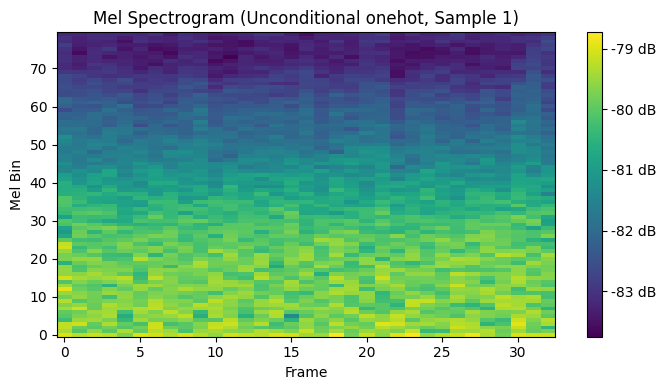

Running onehot conditional inference with vector=[0.0, 1.0, 0.0],  resolved_class=guitar, steps=250
Generated Sample 1 (onehot, class=guitar, steps=250, noise_scale=0.8)


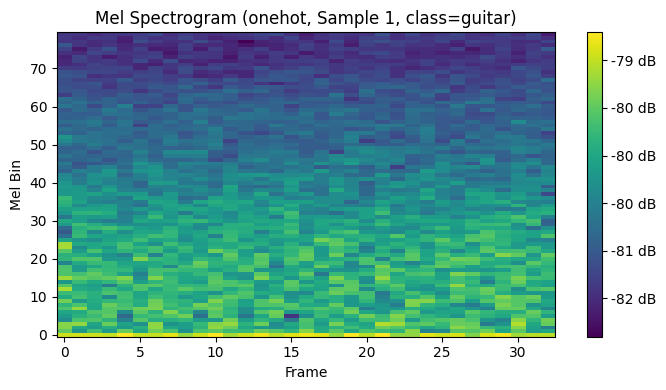


=== Variant: embedding ===
Checkpoint: logs/ckpts/2026-04-19-19-01-59/epoch=702-valid_loss=0.033.ckpt
<All keys matched successfully>
Running unconditional inference for embedding, steps=250
Unconditional Sample 1 (embedding, steps=250, noise_scale=0.8)


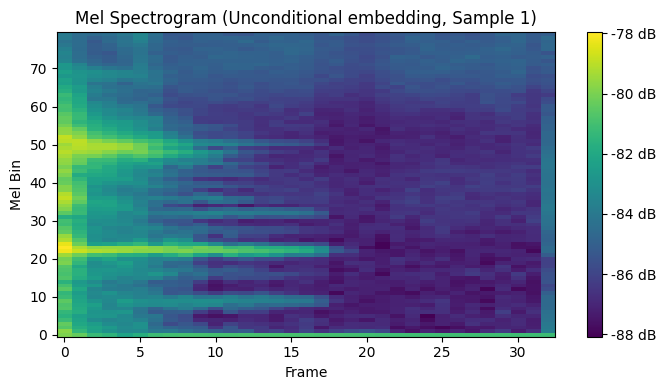

Running embedding conditional inference with prompt='class:bass',  resolved_class=bass, steps=250
Generated Sample 1 (embedding, class=bass, steps=250, noise_scale=0.8)


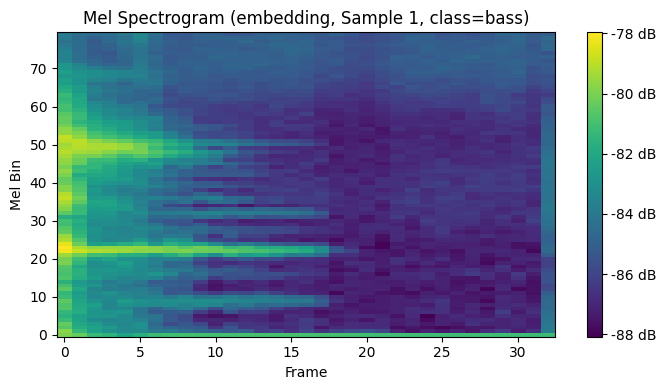

In [24]:
# Generate UNCONDITIONAL + CONDITIONAL samples for BOTH variants (onehot, embedding)
for variant_key in ["onehot", "embedding"]:
    variant = model_variants[variant_key]
    ckpt_path = variant["ckpt_path"]
    config_path = variant["config_path"]
    text_prompt = variant["text_prompt"]
    condition_vector = variant["condition_vector"]
    conditioning_mode_override = variant.get("conditioning_mode_override")

    # Load config for this variant
    with open(config_path, "r", encoding="utf-8") as file:
        raw_config = yaml.safe_load(file)
    config = _resolve_simple_refs(raw_config, raw_config)

    pl_configs = config["model"]
    model_configs = config["model"]["model"]
    model_target = str(config["model"].get("_target_", ""))
    is_embedding_model = "EmbeddingConditionalModel" in model_target
    is_conditional = ("ConditionalModel" in model_target) or is_embedding_model

    if conditioning_mode_override is not None:
        pl_configs["conditioning_mode"] = conditioning_mode_override

    conditioning_mode = pl_configs.get("conditioning_mode", "onehot")
    conditioning_dim = int(pl_configs.get("conditioning_dim", config.get("conditioning_dim", 3)))
    class_names = ["bass", "guitar", "keyboard"]

    # Instantiate model for this variant
    core_kwargs = dict(
        net_t=UNetV0,
        in_channels=model_configs["in_channels"],
        channels=model_configs["channels"],
        factors=model_configs["factors"],
        items=model_configs["items"],
        attentions=model_configs["attentions"],
        attention_heads=model_configs["attention_heads"],
        attention_features=model_configs["attention_features"],
        diffusion_t=VDiffusion,
        sampler_t=VSampler,
    )
    if "embedding_features" in model_configs:
        core_kwargs["embedding_features"] = model_configs["embedding_features"]

    core_model = DiffusionModel(**core_kwargs)

    if is_conditional:
        if is_embedding_model:
            model = EmbeddingConditionalModel(
                lr=pl_configs["lr"],
                lr_beta1=pl_configs["lr_beta1"],
                lr_beta2=pl_configs["lr_beta2"],
                lr_eps=pl_configs["lr_eps"],
                lr_weight_decay=pl_configs["lr_weight_decay"],
                ema_beta=pl_configs["ema_beta"],
                ema_power=pl_configs["ema_power"],
                model=core_model,
                conditioning_dim=pl_configs.get("conditioning_dim", config.get("conditioning_dim", 3)),
                conditioning_mode=pl_configs.get("conditioning_mode", "onehot"),
                conditioning_dropout=pl_configs.get("conditioning_dropout", 0.0),
                num_classes=pl_configs.get("num_classes", pl_configs.get("conditioning_dim", 3)),
                label_embedding_dim=pl_configs.get("label_embedding_dim", 32),
                use_contrastive_loss=pl_configs.get("use_contrastive_loss", False),
                contrastive_weight=pl_configs.get("contrastive_weight", 0.1),
                contrastive_temperature=pl_configs.get("contrastive_temperature", 0.1),
                contrastive_projection_dim=pl_configs.get("contrastive_projection_dim", 64),
            )
        else:
            model = ConditionalModel(
                lr=pl_configs["lr"],
                lr_beta1=pl_configs["lr_beta1"],
                lr_beta2=pl_configs["lr_beta2"],
                lr_eps=pl_configs["lr_eps"],
                lr_weight_decay=pl_configs["lr_weight_decay"],
                ema_beta=pl_configs["ema_beta"],
                ema_power=pl_configs["ema_power"],
                model=core_model,
                audio_channels=config["audio_channels"],
                conditioning_dim=pl_configs.get("conditioning_dim", config.get("conditioning_dim", 3)),
                conditioning_mode=pl_configs.get("conditioning_mode", "onehot"),
                conditioning_dropout=pl_configs.get("conditioning_dropout", 0.0),
                num_classes=pl_configs.get("num_classes", pl_configs.get("conditioning_dim", 3)),
                label_embedding_dim=pl_configs.get("label_embedding_dim", 32),
                use_contrastive_loss=pl_configs.get("use_contrastive_loss", False),
                contrastive_weight=pl_configs.get("contrastive_weight", 0.1),
                contrastive_temperature=pl_configs.get("contrastive_temperature", 0.1),
                contrastive_projection_dim=pl_configs.get("contrastive_projection_dim", 64),
            )
    else:
        model = Model(
            lr=pl_configs["lr"],
            lr_beta1=pl_configs["lr_beta1"],
            lr_beta2=pl_configs["lr_beta2"],
            lr_eps=pl_configs["lr_eps"],
            lr_weight_decay=pl_configs["lr_weight_decay"],
            ema_beta=pl_configs["ema_beta"],
            ema_power=pl_configs["ema_power"],
            model=core_model,
        )

    if torch.cuda.is_available():
        model = model.to("cuda")

    state_dict = torch.load(ckpt_path, map_location="cpu")["state_dict"]
    load_result = model.load_state_dict(state_dict, strict=False)

    sample_length_local = int(config["length"])
    sr_local = int(config["sampling_rate"])
    audio_channels_local = int(config.get("audio_channels", 1))

    class_to_id = {name: idx for idx, name in enumerate(class_names)}

    print(f"\n=== Variant: {variant_key} ===")
    print(f"Checkpoint: {ckpt_path}")
    print(load_result)

    # UNCONDITIONAL
    print(f"Running unconditional inference for {variant_key}, steps={num_steps}")
    all_unconditional = torch.zeros(audio_channels_local, 0)
    for i in range(num_samples):
        gen = torch.Generator(device=model.device).manual_seed(seed + i)
        noise = torch.randn((1, audio_channels_local, sample_length_local), generator=gen, device=model.device) * noise_scale

        if conditioning_mode == "onehot":
            zero_cond = torch.zeros((1, conditioning_dim), dtype=torch.float32, device=model.device)
            generated_sample = model.sample_conditioned(
                noise=noise,
                num_steps=num_steps,
                conditioning=zero_cond,
                class_ids=None,
                use_ema_model=True,
            ).squeeze(0).cpu()
        else:
            generated_sample = model.model_ema.ema_model.sample(noise, num_steps=num_steps).squeeze(0).cpu()

        generated_sample = postprocess_audio(generated_sample, sr=sr_local)

        print(f"Unconditional Sample {i+1} ({variant_key}, steps={num_steps}, noise_scale={noise_scale})")
        display(ipd.Audio(generated_sample, rate=sr_local))

        all_unconditional = torch.concat((all_unconditional, generated_sample), dim=1)
        fig = plot_mel_spectrogram(generated_sample)
        plt.title(f"Mel Spectrogram (Unconditional {variant_key}, Sample {i+1})")
        plt.show()

    # CONDITIONAL
    resolved_class, cond_inputs, generated = generate_conditioned_samples(
        num_samples=num_samples,
        num_steps=num_steps,
        sample_length=sample_length_local,
        sr=sr_local,
        audio_channels=audio_channels_local,
        noise_scale=noise_scale,
        seed=seed,
        text_prompt=text_prompt,
        condition_vector=condition_vector,
    )

    if conditioning_mode == "onehot":
        print(
            f"Running onehot conditional inference with vector={condition_vector}, ",
            f"resolved_class={resolved_class}, steps={num_steps}"
        )
    else:
        print(
            f"Running embedding conditional inference with prompt='{text_prompt}', ",
            f"resolved_class={resolved_class}, steps={num_steps}"
        )

    all_samples = torch.zeros(audio_channels_local, 0)
    for i, generated_sample in enumerate(generated, start=1):
        print(
            f"Generated Sample {i} ({variant_key}, class={resolved_class}, steps={num_steps}, noise_scale={noise_scale})"
        )
        display(ipd.Audio(generated_sample, rate=sr_local))

        all_samples = torch.concat((all_samples, generated_sample), dim=1)

        fig = plot_mel_spectrogram(generated_sample)
        plt.title(f"Mel Spectrogram ({variant_key}, Sample {i}, class={resolved_class})")
        plt.show()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

#### Combine all samples
- Option to combine all samples into a single sample

All Samples


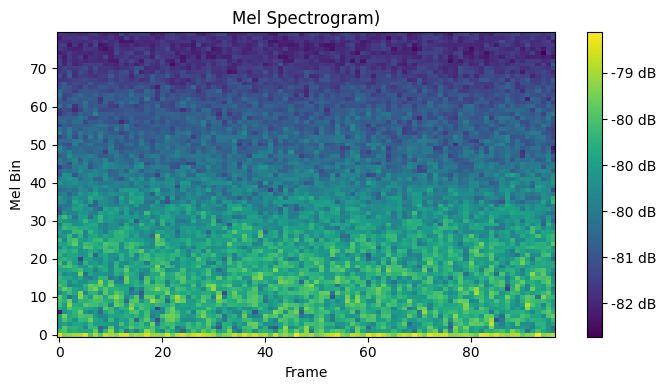

In [12]:
# Optional concatenate all samples
print(f"All Samples")
display(ipd.Audio(all_samples, rate=sr))
fig = plot_mel_spectrogram(all_samples)
plt.title(f"Mel Spectrogram)")
plt.show()

#### Baseline quality check
- Computes simple audio descriptors for each generated sample so you can track consistency and rough hi-hat characteristics.
- For hi-hats, you should generally expect relatively high spectral centroid and zero-crossing rate compared with low-frequency drums.

In [13]:
def baseline_audio_metrics(sample, sr):
    if sample.ndim == 2:
        mono = sample.mean(dim=0)
    else:
        mono = sample
    mono = mono.float()

    rms = torch.sqrt(torch.mean(mono ** 2)).item()
    peak = torch.max(torch.abs(mono)).item()
    zcr = torch.mean((mono[:-1] * mono[1:] < 0).float()).item()

    spectrum = torch.fft.rfft(mono)
    magnitude = torch.abs(spectrum) + 1e-12
    freqs = torch.fft.rfftfreq(mono.numel(), d=1.0 / sr)

    centroid = ((freqs * magnitude).sum() / magnitude.sum()).item()
    cumsum = torch.cumsum(magnitude, dim=0)
    rolloff_idx = torch.searchsorted(cumsum, 0.85 * cumsum[-1]).item()
    rolloff_idx = min(int(rolloff_idx), freqs.numel() - 1)
    rolloff = freqs[rolloff_idx].item()

    return {
        "rms": rms,
        "peak": peak,
        "zcr": zcr,
        "spectral_centroid_hz": centroid,
        "rolloff_85_hz": rolloff,
    }

if all_samples.shape[1] % sample_length == 0 and all_samples.shape[1] > 0:
    split_samples = torch.split(all_samples, sample_length, dim=1)
    print("Baseline metrics per generated sample:")
    for i, sample in enumerate(split_samples, start=1):
        metrics = baseline_audio_metrics(sample, sr)
        print(
            f"Sample {i}: "
            f"RMS={metrics['rms']:.4f}, "
            f"Peak={metrics['peak']:.4f}, "
            f"ZCR={metrics['zcr']:.4f}, "
            f"Centroid={metrics['spectral_centroid_hz']:.1f} Hz, "
            f"Rolloff85={metrics['rolloff_85_hz']:.1f} Hz"
        )
else:
    print("Skipping baseline split metrics because sample lengths are inconsistent.")

Baseline metrics per generated sample:
Sample 1: RMS=0.1390, Peak=0.6270, ZCR=0.1874, Centroid=2493.3 Hz, Rolloff85=5224.6 Hz
Sample 2: RMS=0.1420, Peak=0.5264, ZCR=0.1867, Centroid=2461.1 Hz, Rolloff85=5157.2 Hz
Sample 3: RMS=0.1413, Peak=0.5025, ZCR=0.1853, Centroid=2496.1 Hz, Rolloff85=5233.4 Hz


## Conditional "Style-Transfer" Generation
Generate new sounds conditioned on input audio.


#### Define Sample Parameters
- audio_file_path: Path to audio file for conditioning the model.
- sample_with_noise: Option to output the conditioning sample with noise added to listen, or suppress it.
- trim_sample: Option to trim/pad sample if it is too long/short.
- sample_length: how long to make the output (measured in samples). Recommended $2^{15}=32768$ (~0.75 sec), as that is what the model was trained on.
- sr (sample rate): sampling rate to output. Recommended industry standard 44.1kHz (44100Hz).
- num_samples: number of new samples that will be generated.
- noise_level: The amount of noise to be added to the input sample.
- num_steps: number of diffusion steps - tradeoff inference speed for sample quality.
  - The number of steps for conditional diffusion varies more compared to unconditional diffusion. For example, if you input a transient sound (like a snare hit) and want to transfer it to the `kicks` model, then you may not want to add any noise and keep the steps below 10 for an interesting sound. But, if you want to transfer something like a guitar to the percussion model, you may want to add some more noise and increase the number of steps.

*NOTE:* The less noise that is added to a sample, the less varied the outputs will be. For example, if you ad 0 noise to a sample and generate it 3 times, it will produce the exact same thing 3 times (because the input remains consistent). As you increase the noise added, increasing the variation of the inputs, the outputs will vary more widely as well.

In [14]:
# Define conditional style-transfer parameters (cleaner defaults)
audio_file_path = "data/nsynth_guitar/wav_dataset/guitar_00000.wav"

# Used by label_embedding mode
text_prompt = default_text_prompt

# Used by onehot mode; ignored by label_embedding mode
condition_vector = default_condition_vector  # [bass, guitar, keyboard]

sample_with_noise = True

sample_length = config["length"]
sr = config["sampling_rate"]
audio_channels = config.get("audio_channels", 1)
num_samples = 1
noise_level = 0.15
num_steps = 250
seed = 456

#### Generate samples
Run the following cell to generate samples based on previously defined parameters


=== Variant: onehot ===
Checkpoint: logs/ckpts/2026-04-19-17-22-41/epoch=141-valid_loss=0.033.ckpt
_IncompatibleKeys(missing_keys=['audio_to_latent.weight', 'audio_to_latent.bias', 'text_embedding.weight', 'text_to_latent.weight', 'text_to_latent.bias'], unexpected_keys=[])
Resolved class from onehot vector [0.0, 1.0, 0.0]: guitar
Original Sample (onehot)


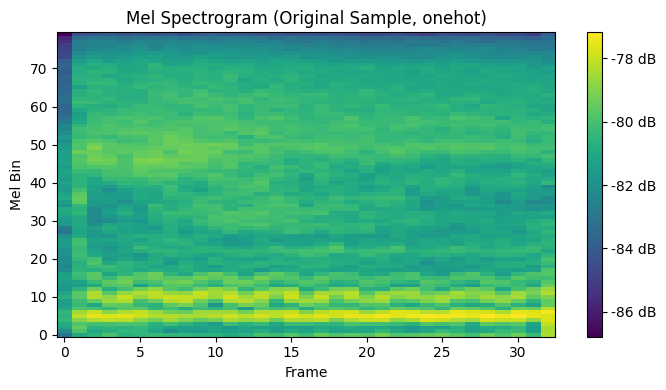

Original Noised Sample (onehot)


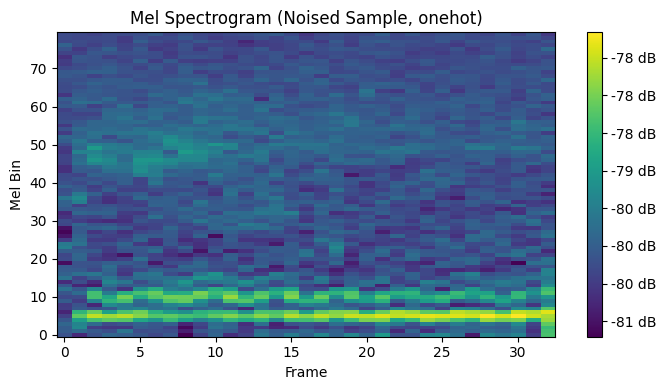

Generated Sample 1 (onehot, class=guitar, steps=250, noise=0.15)


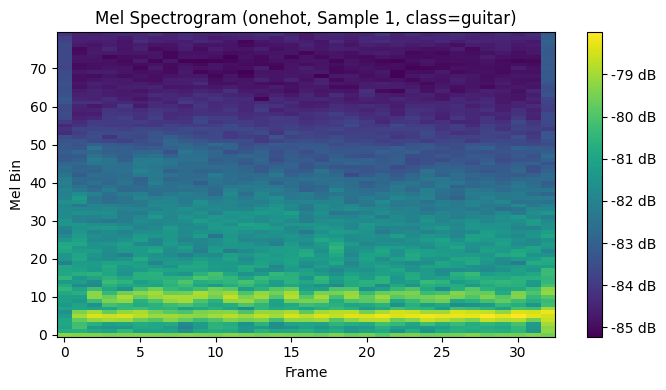


=== Variant: embedding ===
Checkpoint: logs/ckpts/2026-04-19-19-01-59/epoch=702-valid_loss=0.033.ckpt
<All keys matched successfully>
Resolved class from prompt 'class:bass': bass
Original Sample (embedding)


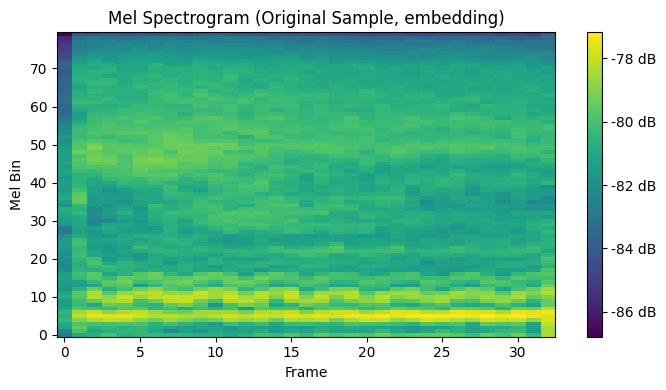

Original Noised Sample (embedding)


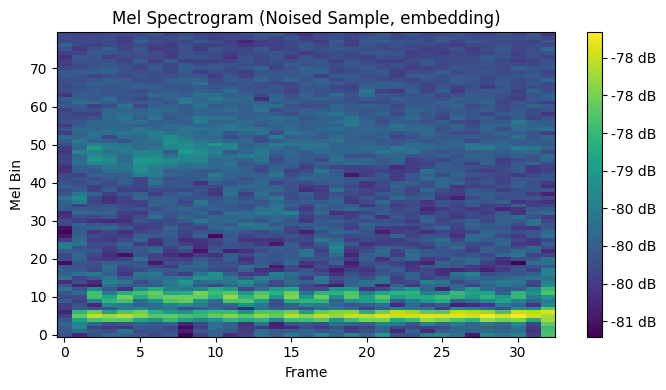

Generated Sample 1 (embedding, class=bass, steps=250, noise=0.15)


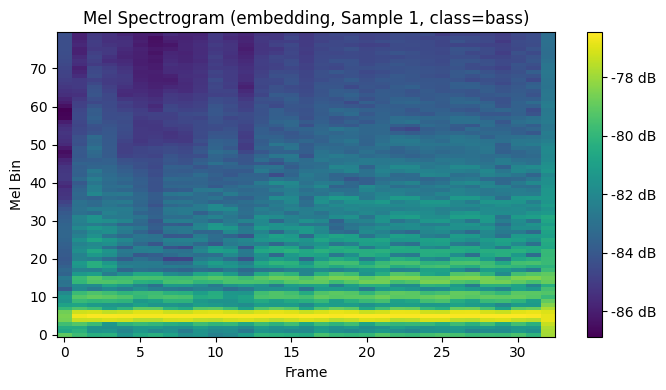

In [25]:
# Generate conditional samples from an input audio seed for BOTH variants
for variant_key in ["onehot", "embedding"]:
    variant = model_variants[variant_key]
    ckpt_path = variant["ckpt_path"]
    config_path = variant["config_path"]
    text_prompt = variant["text_prompt"]
    condition_vector = variant["condition_vector"]
    conditioning_mode_override = variant.get("conditioning_mode_override")

    # Load config for this variant
    with open(config_path, "r", encoding="utf-8") as file:
        raw_config = yaml.safe_load(file)
    config = _resolve_simple_refs(raw_config, raw_config)

    pl_configs = config["model"]
    model_configs = config["model"]["model"]
    model_target = str(config["model"].get("_target_", ""))
    is_embedding_model = "EmbeddingConditionalModel" in model_target
    is_conditional = ("ConditionalModel" in model_target) or is_embedding_model

    if conditioning_mode_override is not None:
        pl_configs["conditioning_mode"] = conditioning_mode_override

    conditioning_mode = pl_configs.get("conditioning_mode", "onehot")
    conditioning_dim = int(pl_configs.get("conditioning_dim", config.get("conditioning_dim", 3)))
    class_names = ["bass", "guitar", "keyboard"]

    # Instantiate model for this variant
    core_kwargs = dict(
        net_t=UNetV0,
        in_channels=model_configs["in_channels"],
        channels=model_configs["channels"],
        factors=model_configs["factors"],
        items=model_configs["items"],
        attentions=model_configs["attentions"],
        attention_heads=model_configs["attention_heads"],
        attention_features=model_configs["attention_features"],
        diffusion_t=VDiffusion,
        sampler_t=VSampler,
    )
    if "embedding_features" in model_configs:
        core_kwargs["embedding_features"] = model_configs["embedding_features"]

    core_model = DiffusionModel(**core_kwargs)

    if is_conditional:
        if is_embedding_model:
            model = EmbeddingConditionalModel(
                lr=pl_configs["lr"],
                lr_beta1=pl_configs["lr_beta1"],
                lr_beta2=pl_configs["lr_beta2"],
                lr_eps=pl_configs["lr_eps"],
                lr_weight_decay=pl_configs["lr_weight_decay"],
                ema_beta=pl_configs["ema_beta"],
                ema_power=pl_configs["ema_power"],
                model=core_model,
                conditioning_dim=pl_configs.get("conditioning_dim", config.get("conditioning_dim", 3)),
                conditioning_mode=pl_configs.get("conditioning_mode", "onehot"),
                conditioning_dropout=pl_configs.get("conditioning_dropout", 0.0),
                num_classes=pl_configs.get("num_classes", pl_configs.get("conditioning_dim", 3)),
                label_embedding_dim=pl_configs.get("label_embedding_dim", 32),
                use_contrastive_loss=pl_configs.get("use_contrastive_loss", False),
                contrastive_weight=pl_configs.get("contrastive_weight", 0.1),
                contrastive_temperature=pl_configs.get("contrastive_temperature", 0.1),
                contrastive_projection_dim=pl_configs.get("contrastive_projection_dim", 64),
            )
        else:
            model = ConditionalModel(
                lr=pl_configs["lr"],
                lr_beta1=pl_configs["lr_beta1"],
                lr_beta2=pl_configs["lr_beta2"],
                lr_eps=pl_configs["lr_eps"],
                lr_weight_decay=pl_configs["lr_weight_decay"],
                ema_beta=pl_configs["ema_beta"],
                ema_power=pl_configs["ema_power"],
                model=core_model,
                audio_channels=config["audio_channels"],
                conditioning_dim=pl_configs.get("conditioning_dim", config.get("conditioning_dim", 3)),
                conditioning_mode=pl_configs.get("conditioning_mode", "onehot"),
                conditioning_dropout=pl_configs.get("conditioning_dropout", 0.0),
                num_classes=pl_configs.get("num_classes", pl_configs.get("conditioning_dim", 3)),
                label_embedding_dim=pl_configs.get("label_embedding_dim", 32),
                use_contrastive_loss=pl_configs.get("use_contrastive_loss", False),
                contrastive_weight=pl_configs.get("contrastive_weight", 0.1),
                contrastive_temperature=pl_configs.get("contrastive_temperature", 0.1),
                contrastive_projection_dim=pl_configs.get("contrastive_projection_dim", 64),
            )
    else:
        model = Model(
            lr=pl_configs["lr"],
            lr_beta1=pl_configs["lr_beta1"],
            lr_beta2=pl_configs["lr_beta2"],
            lr_eps=pl_configs["lr_eps"],
            lr_weight_decay=pl_configs["lr_weight_decay"],
            ema_beta=pl_configs["ema_beta"],
            ema_power=pl_configs["ema_power"],
            model=core_model,
        )

    if torch.cuda.is_available():
        model = model.to("cuda")

    state_dict = torch.load(ckpt_path, map_location="cpu")["state_dict"]
    load_result = model.load_state_dict(state_dict, strict=False)

    sample_length_local = int(config["length"])
    sr_local = int(config["sampling_rate"])
    audio_channels_local = int(config.get("audio_channels", 1))

    class_to_id = {name: idx for idx, name in enumerate(class_names)}

    print(f"\n=== Variant: {variant_key} ===")
    print(f"Checkpoint: {ckpt_path}")
    print(load_result)

    # Build conditional inputs
    resolved_class, cond_inputs = build_condition_inputs_from_user_input(
        device=model.device,
        text_prompt=text_prompt,
        condition_vector=condition_vector,
    )

    with torch.no_grad():
        waveform_np, loaded_sr = sf.read(audio_file_path, dtype="float32", always_2d=True)
        audio_sample = torch.from_numpy(waveform_np.T).unsqueeze(0).to(model.device)

        if loaded_sr != sr_local:
            audio_sample = torchaudio.functional.resample(audio_sample, loaded_sr, sr_local)

        if audio_sample.shape[1] != audio_channels_local:
            audio_sample = audio_sample.mean(dim=1, keepdim=True)

        if audio_sample.shape[-1] > sample_length_local:
            audio_sample = audio_sample[..., :sample_length_local]
        elif audio_sample.shape[-1] < sample_length_local:
            pad = sample_length_local - audio_sample.shape[-1]
            audio_sample = torch.nn.functional.pad(audio_sample, (0, pad))

        original_audio = postprocess_audio(audio_sample.squeeze(0).cpu(), sr=sr_local)

        if conditioning_mode == "onehot":
            print(f"Resolved class from onehot vector {condition_vector}: {resolved_class}")
        else:
            print(f"Resolved class from prompt '{text_prompt}': {resolved_class}")
        print(f"Original Sample ({variant_key})")
        display(ipd.Audio(original_audio, rate=sr_local))
        fig = plot_mel_spectrogram(original_audio)
        plt.title(f"Mel Spectrogram (Original Sample, {variant_key})")
        plt.show()

        if sample_with_noise:
            gen = torch.Generator(device=model.device).manual_seed(seed)
            noise = torch.randn(audio_sample.shape, generator=gen, device=model.device) * noise_level
            noised_sample = postprocess_audio((audio_sample + noise).squeeze(0).cpu(), sr=sr_local)
            print(f"Original Noised Sample ({variant_key})")
            display(ipd.Audio(noised_sample, rate=sr_local))
            fig = plot_mel_spectrogram(noised_sample)
            plt.title(f"Mel Spectrogram (Noised Sample, {variant_key})")
            plt.show()

        all_samples = torch.zeros(audio_channels_local, 0)
        for i in range(num_samples):
            gen = torch.Generator(device=model.device).manual_seed(seed + i)
            seed_noise = torch.randn(audio_sample.shape, generator=gen, device=model.device) * noise_level
            seeded_input = audio_sample + seed_noise

            if is_conditional:
                generated_sample = model.sample_conditioned(
                    noise=seeded_input,
                    num_steps=num_steps,
                    conditioning=cond_inputs["conditioning"],
                    class_ids=cond_inputs["class_ids"],
                    use_ema_model=True,
                ).squeeze(0).cpu()
            else:
                generated_sample = model.model_ema.ema_model.sample(seeded_input, num_steps=num_steps).squeeze(0).cpu()

            generated_sample = postprocess_audio(generated_sample, sr=sr_local)
            print(
                f"Generated Sample {i+1} ({variant_key}, class={resolved_class}, steps={num_steps}, noise={noise_level})"
            )
            display(ipd.Audio(generated_sample, rate=sr_local))

            all_samples = torch.concat((all_samples, generated_sample), dim=1)

            fig = plot_mel_spectrogram(generated_sample)
            plt.title(f"Mel Spectrogram ({variant_key}, Sample {i+1}, class={resolved_class})")
            plt.show()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

#### Combine all samples
- Option to combine all samples into a single sample

All Samples


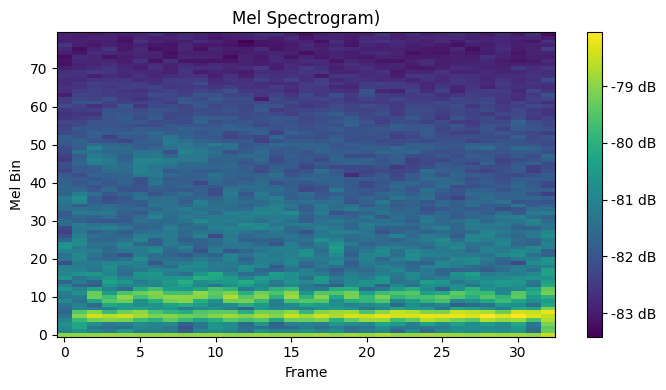

In [16]:
# Optional concatenate all samples
print(f"All Samples")
display(ipd.Audio(all_samples, rate=sr))
fig = plot_mel_spectrogram(all_samples)
plt.title(f"Mel Spectrogram)")
plt.show()

In [17]:
# TODO: Add normalization?
# TODO: Add other smapling methods (currently only DDIM)
# TODO: clean cell (make functions)

### Conditional Noisy Comparison Results
Load and inspect evaluation metrics produced by scripts/evaluate_conditional_noisy_comparison.py.

This compares:
- provided noisy waveforms from metadata,
- synthetic noisy waveforms generated from the clean clips using the noise recipes,
- model outputs when sampling from each noisy source.

## Model Quality Triage
Use this section to objectively check whether the current checkpoint is producing structured audio or mostly noise-like outputs.

It compares a small validation batch against generated samples using:
- RMS
- Zero-crossing rate
- Spectral flatness
- MSE to clean targets

In [18]:
from main.diffusion_module import NSynthConditionalDatamodule

def audio_stats(batch_wave):
    # batch_wave: [B, C, T]
    x = batch_wave[:, 0, :].float()
    rms = torch.sqrt(torch.mean(x ** 2, dim=1)).mean().item()
    zcr = ((x[:, :-1] * x[:, 1:]) < 0).float().mean(dim=1).mean().item()
    spec = torch.fft.rfft(x, dim=1)
    mag = torch.abs(spec) + 1e-10
    flatness = (torch.exp(torch.mean(torch.log(mag), dim=1)) / torch.mean(mag, dim=1)).mean().item()
    return {"rms": rms, "zcr": zcr, "flatness": flatness}

dm = NSynthConditionalDatamodule(
    metadata_path="data/nsynth_waveform_box/metadata/metadata.jsonl",
    batch_size=8,
    num_workers=0,
    pin_memory=False,
    include_spectrogram=False,
    sample_rate=sr,
    target_length=sample_length,
 )
dm.setup("fit")

batch = next(iter(dm.val_dataloader()))
clean = batch["Clean Waveform"].to(model.device)
provided_noisy = batch["Noisy Waveform"].to(model.device)
class_ids = batch["Class Id"].to(model.device)
conditioning = batch.get("Conditioning")
if conditioning is not None:
    conditioning = conditioning.to(model.device)

with torch.no_grad():
    # generation from random noise (hard case)
    noise = torch.randn_like(clean)
    gen_from_noise = model.sample_conditioned(
        noise=noise,
        num_steps=250,
        conditioning=conditioning if conditioning_mode == "onehot" else None,
        class_ids=class_ids,
        use_ema_model=True,
    )

    # generation from provided noisy sample (easier denoise path)
    gen_from_provided_noisy = model.sample_conditioned(
        noise=provided_noisy,
        num_steps=250,
        conditioning=conditioning if conditioning_mode == "onehot" else None,
        class_ids=class_ids,
        use_ema_model=True,
    )

clean_stats = audio_stats(clean.detach().cpu())
noise_stats = audio_stats(gen_from_noise.detach().cpu())
denoise_stats = audio_stats(gen_from_provided_noisy.detach().cpu())

mse_noise = torch.mean((gen_from_noise - clean) ** 2).item()
mse_denoise = torch.mean((gen_from_provided_noisy - clean) ** 2).item()

print("Validation batch quality check")
print("Clean stats:", clean_stats)
print("Gen-from-noise stats:", noise_stats)
print("Gen-from-provided-noisy stats:", denoise_stats)
print(f"MSE(gen_from_noise, clean): {mse_noise:.6f}")
print(f"MSE(gen_from_provided_noisy, clean): {mse_denoise:.6f}")

# quick listen to first example
ref = postprocess_audio(clean[0].detach().cpu(), sr)
g_noise = postprocess_audio(gen_from_noise[0].detach().cpu(), sr)
g_denoise = postprocess_audio(gen_from_provided_noisy[0].detach().cpu(), sr)

print("Reference clean (val sample 1)")
display(ipd.Audio(ref, rate=sr))
print("Generated from random noise (val sample 1 class condition)")
display(ipd.Audio(g_noise, rate=sr))
print("Generated from provided noisy input (val sample 1 class condition)")
display(ipd.Audio(g_denoise, rate=sr))

Validation batch quality check
Clean stats: {'rms': 0.22645354270935059, 'zcr': 0.06231306493282318, 'flatness': 0.1572691798210144}
Gen-from-noise stats: {'rms': 0.20376500487327576, 'zcr': 0.17758499085903168, 'flatness': 0.6290192008018494}
Gen-from-provided-noisy stats: {'rms': 0.11787179857492447, 'zcr': 0.02704785391688347, 'flatness': 0.19905130565166473}
MSE(gen_from_noise, clean): 0.104899
MSE(gen_from_provided_noisy, clean): 0.030532
Reference clean (val sample 1)


Generated from random noise (val sample 1 class condition)


Generated from provided noisy input (val sample 1 class condition)


In [19]:
import json
from pathlib import Path

metrics_path = Path("logs/eval/conditional_noisy_comparison.json")
if not metrics_path.exists():
    raise FileNotFoundError(
        "Missing logs/eval/conditional_noisy_comparison.json. "
        "Run scripts/evaluate_conditional_noisy_comparison.py first."
    )

with metrics_path.open("r", encoding="utf-8") as f:
    noisy_eval = json.load(f)

print("Conditional noisy comparison summary")
print(f"Checkpoint: {noisy_eval['ckpt_path']}")
print(f"Split: {noisy_eval['split']}, Samples: {noisy_eval['total_samples']}")
for key, value in noisy_eval["averages"].items():
    print(f"- {key}: {value:.8f}")

provided_better = noisy_eval["averages"]["output_mse_provided_path"] < noisy_eval["averages"]["output_mse_generated_path"]
print(
    "Provided noisy path has lower output MSE to clean:" if provided_better else "Generated noisy path has lower output MSE to clean:",
    provided_better if provided_better else (not provided_better),
)

Conditional noisy comparison summary
Checkpoint: /home/sammli/tiny-audio-diffusion/logs/ckpts/2026-04-19-15-12-03/epoch=99-valid_loss=0.042.ckpt
Split: test, Samples: 30
- input_mse_provided_vs_generated: 0.00007614
- input_snr_db_provided: 35.10507050
- input_snr_db_generated: 29.42921295
- output_mse_provided_path: 0.03071317
- output_mse_generated_path: 0.03069142
- output_mse_between_paths: 0.00000265
Generated noisy path has lower output MSE to clean: True


In [20]:
# Fast architecture + quality diagnostics for both variants (no audio/plot output)
import copy
from pathlib import Path

def _flatness(x: torch.Tensor) -> float:
    spec = torch.fft.rfft(x)
    mag = torch.abs(spec) + 1e-10
    return float((torch.exp(torch.mean(torch.log(mag))) / torch.mean(mag)).item())

def _centroid(x: torch.Tensor, sr: int) -> float:
    spec = torch.fft.rfft(x)
    mag = torch.abs(spec) + 1e-12
    freqs = torch.fft.rfftfreq(x.numel(), d=1.0 / sr).to(x.device)
    return float(((freqs * mag).sum() / mag.sum()).item())

def _stats(x: torch.Tensor, sr: int) -> dict:
    x = x.float().flatten()
    return {
        "rms": float(torch.sqrt(torch.mean(x ** 2)).item()),
        "zcr": float(((x[:-1] * x[1:]) < 0).float().mean().item()),
        "flatness": _flatness(x),
        "centroid_hz": _centroid(x, sr),
    }

def _resolve_cfg(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        raw = yaml.safe_load(f)
    return _resolve_simple_refs(raw, raw)

def _build_model_for_variant(variant_key: str):
    variant_cfg = model_variants[variant_key]
    cfg = _resolve_cfg(variant_cfg["config_path"])
    pl_cfg = copy.deepcopy(cfg["model"])
    core_cfg = cfg["model"]["model"]
    mode_override = variant_cfg.get("conditioning_mode_override")
    if mode_override is not None:
        pl_cfg["conditioning_mode"] = mode_override

    target = str(pl_cfg.get("_target_", ""))
    is_embed = "EmbeddingConditionalModel" in target

    core_kwargs = dict(
        net_t=UNetV0,
        in_channels=core_cfg["in_channels"],
        channels=core_cfg["channels"],
        factors=core_cfg["factors"],
        items=core_cfg["items"],
        attentions=core_cfg["attentions"],
        attention_heads=core_cfg["attention_heads"],
        attention_features=core_cfg["attention_features"],
        diffusion_t=VDiffusion,
        sampler_t=VSampler,
    )
    if "embedding_features" in core_cfg:
        core_kwargs["embedding_features"] = core_cfg["embedding_features"]

    core_model_local = DiffusionModel(**core_kwargs)
    if is_embed:
        m = EmbeddingConditionalModel(
            lr=pl_cfg["lr"],
            lr_beta1=pl_cfg["lr_beta1"],
            lr_beta2=pl_cfg["lr_beta2"],
            lr_eps=pl_cfg["lr_eps"],
            lr_weight_decay=pl_cfg["lr_weight_decay"],
            ema_beta=pl_cfg["ema_beta"],
            ema_power=pl_cfg["ema_power"],
            model=core_model_local,
            conditioning_dim=pl_cfg.get("conditioning_dim", cfg.get("conditioning_dim", 3)),
            conditioning_mode=pl_cfg.get("conditioning_mode", "onehot"),
            conditioning_dropout=pl_cfg.get("conditioning_dropout", 0.0),
            num_classes=pl_cfg.get("num_classes", pl_cfg.get("conditioning_dim", 3)),
            label_embedding_dim=pl_cfg.get("label_embedding_dim", 32),
            use_contrastive_loss=pl_cfg.get("use_contrastive_loss", False),
            contrastive_weight=pl_cfg.get("contrastive_weight", 0.1),
            contrastive_temperature=pl_cfg.get("contrastive_temperature", 0.1),
            contrastive_projection_dim=pl_cfg.get("contrastive_projection_dim", 64),
        )
    else:
        m = ConditionalModel(
            lr=pl_cfg["lr"],
            lr_beta1=pl_cfg["lr_beta1"],
            lr_beta2=pl_cfg["lr_beta2"],
            lr_eps=pl_cfg["lr_eps"],
            lr_weight_decay=pl_cfg["lr_weight_decay"],
            ema_beta=pl_cfg["ema_beta"],
            ema_power=pl_cfg["ema_power"],
            model=core_model_local,
            audio_channels=cfg["audio_channels"],
            conditioning_dim=pl_cfg.get("conditioning_dim", cfg.get("conditioning_dim", 3)),
            conditioning_mode=pl_cfg.get("conditioning_mode", "onehot"),
            conditioning_dropout=pl_cfg.get("conditioning_dropout", 0.0),
            num_classes=pl_cfg.get("num_classes", pl_cfg.get("conditioning_dim", 3)),
            label_embedding_dim=pl_cfg.get("label_embedding_dim", 32),
            use_contrastive_loss=pl_cfg.get("use_contrastive_loss", False),
            contrastive_weight=pl_cfg.get("contrastive_weight", 0.1),
            contrastive_temperature=pl_cfg.get("contrastive_temperature", 0.1),
            contrastive_projection_dim=pl_cfg.get("contrastive_projection_dim", 64),
        )

    dev = "cuda" if torch.cuda.is_available() else "cpu"
    m = m.to(dev)
    state_dict_local = torch.load(variant_cfg["ckpt_path"], map_location="cpu")["state_dict"]
    load_res = m.load_state_dict(state_dict_local, strict=False)
    return m, cfg, pl_cfg, load_res, variant_cfg

@torch.no_grad()
def _generate_single(m, cfg, pl_cfg, class_idx: int, seed: int = 123, steps: int = 120):
    dev = m.device
    audio_ch = cfg.get("audio_channels", 1)
    length_local = cfg["length"]
    noise = torch.randn((1, audio_ch, length_local), generator=torch.Generator(device=dev).manual_seed(seed), device=dev)

    mode_local = pl_cfg.get("conditioning_mode", "onehot")
    class_id = torch.tensor([class_idx], dtype=torch.long, device=dev)
    if mode_local == "onehot":
        cond = F.one_hot(class_id, num_classes=int(pl_cfg.get("conditioning_dim", 3))).float()
    else:
        cond = None

    out = m.sample_conditioned(
        noise=noise,
        num_steps=steps,
        conditioning=cond,
        class_ids=class_id,
        use_ema_model=True,
    ).squeeze(0).detach().cpu()

    noise_ref = noise.squeeze(0).detach().cpu()
    return out, noise_ref

print("=== Conditional Variant Diagnostics ===")
for key in ["onehot", "embedding"]:
    if key not in model_variants:
        print(f"[{key}] missing in model_variants, skipping")
        continue

    m, cfg_local, pl_cfg_local, load_res_local, variant_used = _build_model_for_variant(key)
    missing = list(load_res_local.missing_keys)
    unexpected = list(load_res_local.unexpected_keys)

    s_bass, n_ref = _generate_single(m, cfg_local, pl_cfg_local, class_idx=0, seed=123, steps=120)
    s_guitar, _ = _generate_single(m, cfg_local, pl_cfg_local, class_idx=1, seed=123, steps=120)

    bass_stats = _stats(s_bass, cfg_local["sampling_rate"])
    guitar_stats = _stats(s_guitar, cfg_local["sampling_rate"])
    noise_stats = _stats(n_ref, cfg_local["sampling_rate"])

    class_sep = abs(bass_stats["centroid_hz"] - guitar_stats["centroid_hz"])
    noise_flatness_delta = bass_stats["flatness"] - noise_stats["flatness"]

    print(f"\n[{key}] ckpt={variant_used['ckpt_path']}")
    print(f"  mode={pl_cfg_local.get('conditioning_mode')} target={pl_cfg_local.get('_target_')}")
    print(f"  load: missing={len(missing)} unexpected={len(unexpected)}")
    if missing:
        print(f"  missing sample: {missing[:5]}")
    if unexpected:
        print(f"  unexpected sample: {unexpected[:5]}")

    print(f"  bass stats:   {bass_stats}")
    print(f"  guitar stats: {guitar_stats}")
    print(f"  noise stats:  {noise_stats}")
    print(f"  class centroid separation (bass vs guitar): {class_sep:.2f} Hz")
    print(f"  flatness delta vs noise (bass - noise): {noise_flatness_delta:.6f}")

    del m
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

=== Conditional Variant Diagnostics ===

[onehot] ckpt=logs/ckpts/2026-04-19-17-22-41/epoch=141-valid_loss=0.033.ckpt
  mode=onehot target=${module}.ConditionalModel
  load: missing=5 unexpected=0
  missing sample: ['audio_to_latent.weight', 'audio_to_latent.bias', 'text_embedding.weight', 'text_to_latent.weight', 'text_to_latent.bias']
  bass stats:   {'rms': 0.20229840278625488, 'zcr': 0.17689068615436554, 'flatness': 0.6217970252037048, 'centroid_hz': 2294.19140625}
  guitar stats: {'rms': 0.16682793200016022, 'zcr': 0.20899713039398193, 'flatness': 0.6754087209701538, 'centroid_hz': 2524.937744140625}
  noise stats:  {'rms': 0.9932702779769897, 'zcr': 0.49813830852508545, 'flatness': 0.8396607637405396, 'centroid_hz': 3998.8984375}
  class centroid separation (bass vs guitar): 230.75 Hz
  flatness delta vs noise (bass - noise): -0.217864

[embedding] ckpt=logs/ckpts/2026-04-19-19-01-59/epoch=702-valid_loss=0.033.ckpt
  mode=label_embedding target=${module}.EmbeddingConditionalModel